In [85]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_from_disk
from PIL import Image

# Reproducibility
random.seed(42)
np.random.seed(42)

# Paths

GZ_RINGS_PATH = 'data/gz_rings_regression'
GZ_EUCLID_PATH = 'data/gz_euclid_default'


In [86]:
gz_rings = load_from_disk(str(GZ_RINGS_PATH))
gz_euclid = load_from_disk(str(GZ_EUCLID_PATH))

print("gz_rings:")
print(gz_rings)
print()
print("gz_euclid:")
print(gz_euclid)

gz_rings:
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 73356
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 18340
    })
})

gz_euclid:
DatasetDict({
    train: Dataset({
        features: ['image', 'id_str', 'dataset_name', 'smooth-or-featured-euclid_smooth', 'smooth-or-featured-euclid_smooth_fraction', 'smooth-or-featured-euclid_total-votes', 'smooth-or-featured-euclid_featured-or-disk', 'smooth-or-featured-euclid_featured-or-disk_fraction', 'smooth-or-featured-euclid_problem', 'smooth-or-featured-euclid_problem_fraction', 'disk-edge-on-euclid_yes', 'disk-edge-on-euclid_yes_fraction', 'disk-edge-on-euclid_total-votes', 'disk-edge-on-euclid_no', 'disk-edge-on-euclid_no_fraction', 'has-spiral-arms-euclid_yes', 'has-spiral-arms-euclid_yes_fraction', 'has-spiral-arms-euclid_total-votes', 'has-spiral-arms-euclid_no', 'has-spiral-arms-euclid_no_fraction', 'bar-euclid_strong', 'bar-euclid_strong_fraction', 'ba

In [87]:
def dataset_summary(ds_dict, name):
    print(f"=== {name} ===")
    for split in ds_dict.keys():
        ds = ds_dict[split]
        print(f"\n[{split}]")
        print(f"num_rows: {len(ds)}")
        print(f"features: {list(ds.features.keys())[:10]}{' ...' if len(ds.features) > 10 else ''}")

dataset_summary(gz_rings, "gz_rings_regression")
print()
dataset_summary(gz_euclid, "gz_euclid_default")

=== gz_rings_regression ===

[train]
num_rows: 73356
features: ['image', 'label']

[test]
num_rows: 18340
features: ['image', 'label']

=== gz_euclid_default ===

[train]
num_rows: 169899
features: ['image', 'id_str', 'dataset_name', 'smooth-or-featured-euclid_smooth', 'smooth-or-featured-euclid_smooth_fraction', 'smooth-or-featured-euclid_total-votes', 'smooth-or-featured-euclid_featured-or-disk', 'smooth-or-featured-euclid_featured-or-disk_fraction', 'smooth-or-featured-euclid_problem', 'smooth-or-featured-euclid_problem_fraction'] ...

[test]
num_rows: 2378
features: ['image', 'id_str', 'dataset_name', 'smooth-or-featured-euclid_smooth', 'smooth-or-featured-euclid_smooth_fraction', 'smooth-or-featured-euclid_total-votes', 'smooth-or-featured-euclid_featured-or-disk', 'smooth-or-featured-euclid_featured-or-disk_fraction', 'smooth-or-featured-euclid_problem', 'smooth-or-featured-euclid_problem_fraction'] ...


In [88]:
rings_sample = gz_rings["train"][0]
euclid_sample = gz_euclid["train"][0]

print("gz_rings sample keys:", rings_sample.keys())
print("gz_rings label:", rings_sample["label"])
print("gz_rings image type:", type(rings_sample["image"]))

print("\ngz_euclid sample keys (first 20):", list(euclid_sample.keys())[:20])
print("gz_euclid id_str:", euclid_sample["id_str"])
print("gz_euclid image type:", type(euclid_sample["image"]))

gz_rings sample keys: dict_keys(['image', 'label'])
gz_rings label: 0.6000000238418579
gz_rings image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>

gz_euclid sample keys (first 20): ['image', 'id_str', 'dataset_name', 'smooth-or-featured-euclid_smooth', 'smooth-or-featured-euclid_smooth_fraction', 'smooth-or-featured-euclid_total-votes', 'smooth-or-featured-euclid_featured-or-disk', 'smooth-or-featured-euclid_featured-or-disk_fraction', 'smooth-or-featured-euclid_problem', 'smooth-or-featured-euclid_problem_fraction', 'disk-edge-on-euclid_yes', 'disk-edge-on-euclid_yes_fraction', 'disk-edge-on-euclid_total-votes', 'disk-edge-on-euclid_no', 'disk-edge-on-euclid_no_fraction', 'has-spiral-arms-euclid_yes', 'has-spiral-arms-euclid_yes_fraction', 'has-spiral-arms-euclid_total-votes', 'has-spiral-arms-euclid_no', 'has-spiral-arms-euclid_no_fraction']
gz_euclid id_str: 000025c0749f53d1109ce125cc55d436ab993c64189836406e9a097a02607c83
gz_euclid image type: <class 'PIL.JpegImagePlugin.JpegI

In [91]:
def to_numpy_image(img):


    arr = np.array(img)

    # If CHW, move to HWC
    if arr.ndim == 3 and arr.shape[0] in [1, 3, 4] and arr.shape[0] < arr.shape[-1]:
        arr = np.transpose(arr, (1, 2, 0))
    return arr

def show_dataset_samples(ds, n=9, label_key=None, title=None, cols=3, figsize=(12, 12)):
    indices = random.sample(range(len(ds)), n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, indices):
        sample = ds[idx]
        img = to_numpy_image(sample["image"])
        ax.imshow(img)
        ax.axis("off")

        if label_key is not None and label_key in sample:
            ax.set_title(f"{label_key}={sample[label_key]:.3f}", fontsize=12)
        else:
            ax.set_title(f"idx={idx}", fontsize=10)

    for ax in axes[n:]:
        ax.axis("off")

    if title is not None:
        fig.suptitle(title, fontsize=20, y = 1.0)
    plt.tight_layout()
    plt.savefig(f'galaxy_examples_euclid.pdf')
    plt.show()

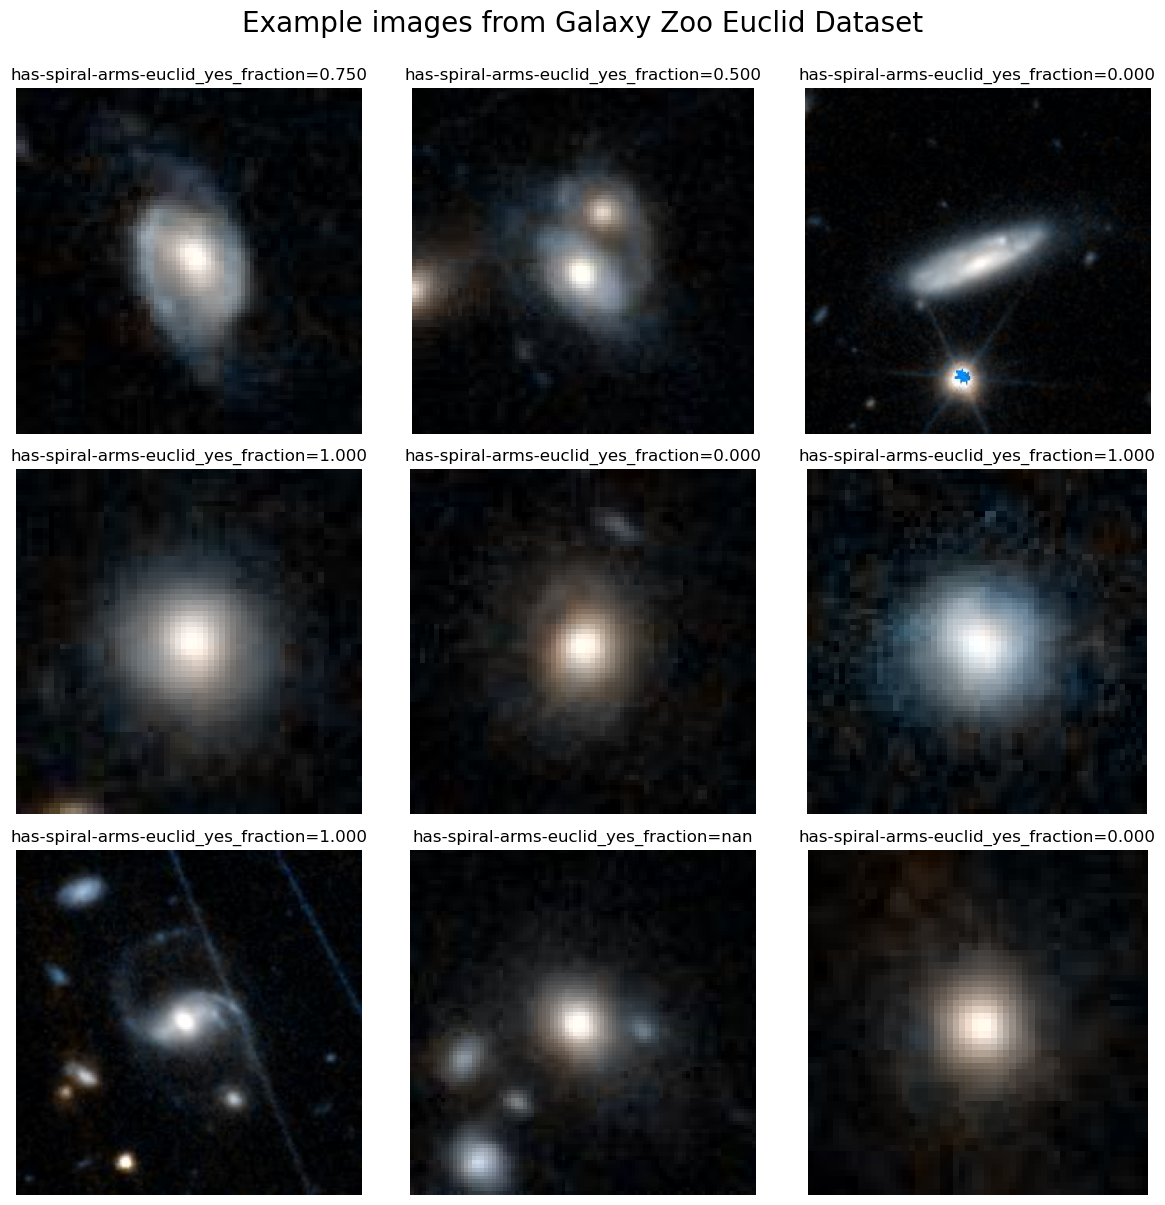

In [92]:
show_dataset_samples(
    gz_euclid["train"],
    n=9,
    label_key='has-spiral-arms-euclid_yes_fraction',
    title="Example images from Galaxy Zoo Euclid Dataset"
)

In [93]:
def inspect_image_shapes(ds, n=200):
    idxs = np.random.choice(len(ds), size=min(n, len(ds)), replace=False)
    shapes = []

    for idx in idxs:
        img = to_numpy_image(ds[int(idx)]["image"])
        shapes.append(img.shape)

    shape_counts = pd.Series(shapes).value_counts()
    return shape_counts

print("gz_rings shape counts:")
display(inspect_image_shapes(gz_rings["train"], n=500).head(10))

print("\ngz_euclid shape counts:")
display(inspect_image_shapes(gz_euclid["train"], n=500).head(10))

gz_rings shape counts:


(424, 424, 3)    500
Name: count, dtype: int64


gz_euclid shape counts:


(77, 77, 3)    15
(72, 72, 3)    13
(62, 62, 3)    12
(68, 68, 3)    10
(75, 75, 3)     9
(76, 76, 3)     9
(82, 82, 3)     7
(65, 65, 3)     7
(79, 79, 3)     7
(94, 94, 3)     7
Name: count, dtype: int64

(73356,)
Train label stats:
count    73356.000000
mean         0.472219
std          0.258661
min          0.000000
25%          0.272727
50%          0.500000
75%          0.700000
max          1.000000
dtype: float64

Test label stats:
count    18340.000000
mean         0.471626
std          0.257619
min          0.000000
25%          0.272727
50%          0.500000
75%          0.700000
max          1.000000
dtype: float64


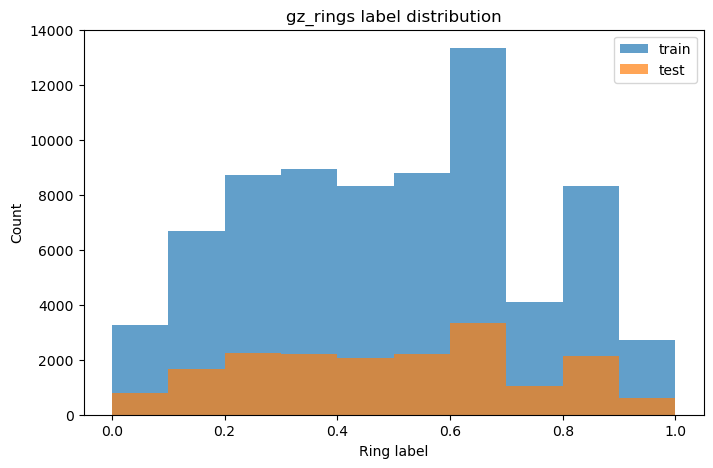

In [96]:
train_labels = np.array(gz_rings["train"]["label"])
print(train_labels.shape)
test_labels = np.array(gz_rings["test"]["label"])

print("Train label stats:")
print(pd.Series(train_labels).describe())

print("\nTest label stats:")
print(pd.Series(test_labels).describe())

plt.figure(figsize=(8, 5))
plt.hist(train_labels, bins=10, alpha=0.7, label="train")
plt.hist(test_labels, bins=10, alpha=0.7, label="test")
plt.xlabel("Ring label")
plt.ylabel("Count")
plt.title("gz_rings label distribution")
plt.legend()
plt.savefig('label_distribution.pdf')
plt.show()

In [95]:
unique_labels = np.unique(train_labels)
print(f"Number of unique train labels: {len(unique_labels)}")
print("First 50 unique labels:")
print(unique_labels[:50])

# Show the most common labels
label_counts = pd.Series(train_labels).value_counts().sort_index()
display(label_counts.head(20))
display(label_counts.tail(20))

Number of unique train labels: 260
First 50 unique labels:
[0.         0.07142857 0.07692308 0.08333334 0.09090909 0.1
 0.14285715 0.15000001 0.15384616 0.16666667 0.18181819 0.1875
 0.2        0.21428572 0.23076923 0.23809524 0.25       0.26666668
 0.27272728 0.28476822 0.2857143  0.28708133 0.30000001 0.30088496
 0.30107528 0.30729166 0.30769232 0.31162789 0.3125     0.31999999
 0.32085562 0.33173078 0.33333334 0.33519554 0.33862433 0.34782609
 0.34951457 0.34999999 0.35648149 0.35714287 0.36000001 0.36363637
 0.37096775 0.37320575 0.375      0.38095239 0.38461539 0.38586956
 0.39130434 0.39644971]


0.000000    2408
0.071429       6
0.076923       7
0.083333      38
0.090909     826
0.100000    5468
0.142857       8
0.150000       1
0.153846       6
0.166667      47
0.181818    1174
0.187500       1
0.200000    7555
0.214286       3
0.230769      16
0.238095       1
0.250000      56
0.266667       3
0.272727    1094
0.284768       1
Name: count, dtype: int64

0.920000       7
0.923077     120
0.928571      77
0.931035       1
0.933333      36
0.937500      15
0.941176       4
0.944444       6
0.947368       4
0.950000      69
0.950820       1
0.952381      59
0.954545      23
0.956522      10
0.958333       5
0.960000       4
0.967742       2
0.983051       1
0.983607       1
1.000000    1121
Name: count, dtype: int64

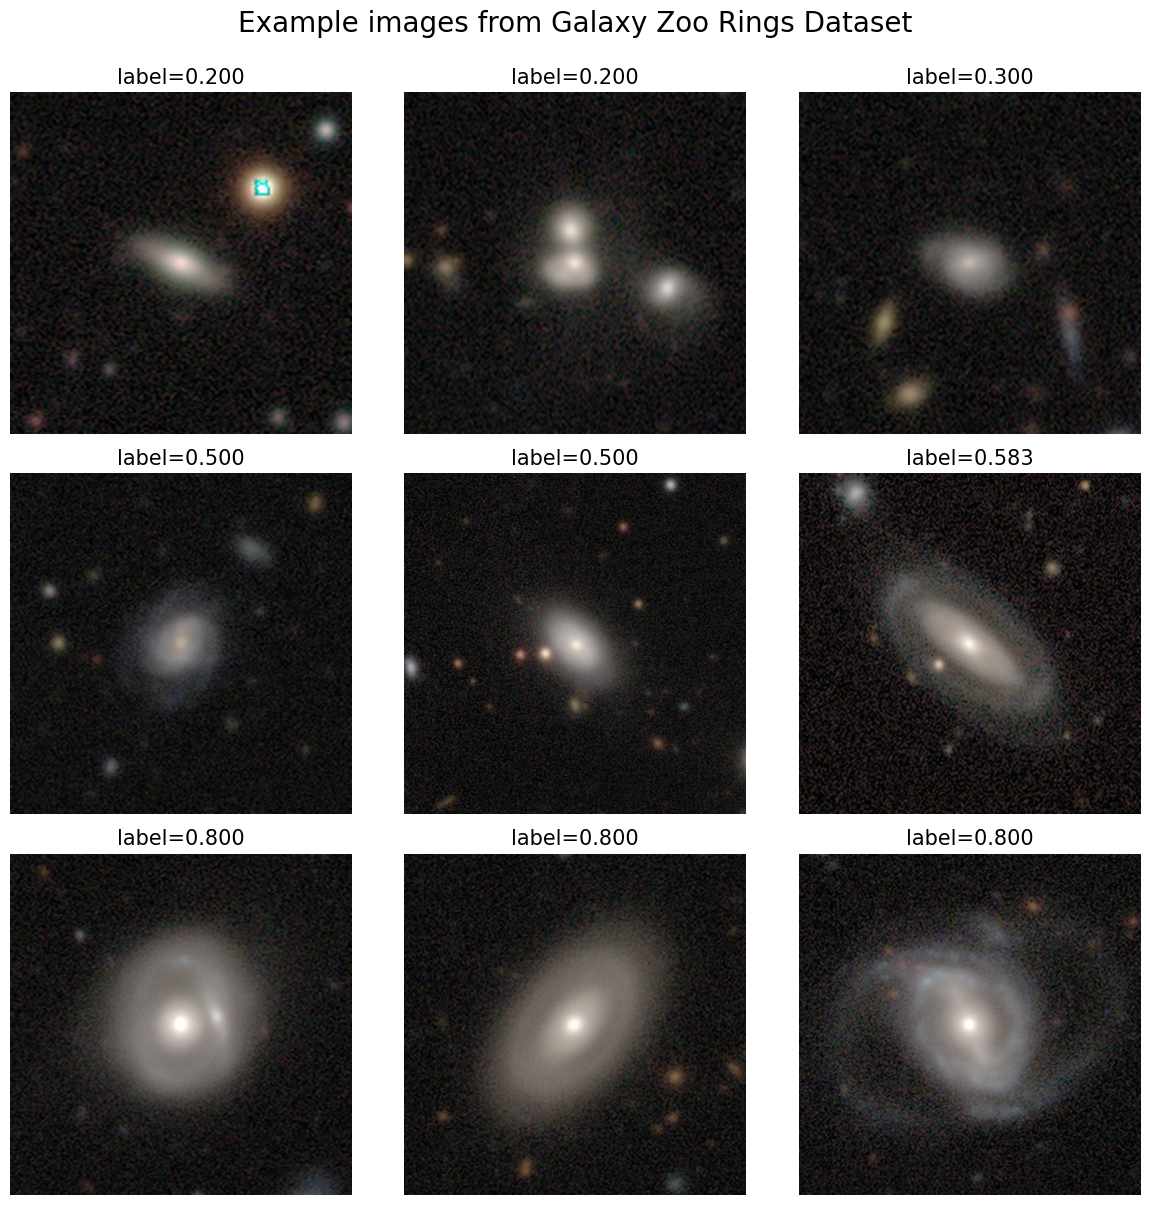

In [53]:
def show_combined_examples(ds, ranges, n_per_range=8, cols=3):
    # Calculate total images to determine grid size
    all_chosen = []
    for low, high in ranges:
        idxs = [i for i, y in enumerate(ds["label"]) if low <= y < high]
        if idxs:
            chosen = random.sample(idxs, min(n_per_range, len(idxs)))
            all_chosen.extend(chosen)

    if not all_chosen:
        print("No examples found for any range.")
        return

    rows = int(np.ceil(len(all_chosen) / cols))
    # Using 16x4 per row for significant image size increase
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = np.array(axes).flatten()

    for i, idx in enumerate(all_chosen):
        sample = ds[idx]
        img = to_numpy_image(sample["image"])
        axes[i].imshow(img)
        axes[i].set_title(f"label={sample['label']:.3f}", fontsize=15)
        axes[i].axis("off")

    # Clean up empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle('Example images from Galaxy Zoo Rings Dataset', fontsize = 20, y = 1.0)
    plt.tight_layout()
    plt.savefig('examples_gz_rings.pdf')
    plt.show()

# Call it once with all your ranges
ranges = [(0.0, 0.4), (0.401, 0.6), (0.601, 1.01)]
show_combined_examples(gz_rings["train"], ranges, n_per_range=3)


In [12]:
def compute_pixel_stats(ds, n=1000):
    idxs = np.random.choice(len(ds), size=min(n, len(ds)), replace=False)

    channel_sums = None
    channel_sq_sums = None
    pixel_count = 0

    min_val = np.inf
    max_val = -np.inf

    for idx in idxs:
        img = to_numpy_image(ds[int(idx)]["image"]).astype(np.float32)

        # Normalize if uint8-like
        if img.max() > 1.0:
            img = img / 255.0

        if img.ndim == 2:
            img = img[..., None]

        h, w, c = img.shape
        flat = img.reshape(-1, c)

        if channel_sums is None:
            channel_sums = flat.sum(axis=0)
            channel_sq_sums = (flat ** 2).sum(axis=0)
        else:
            channel_sums += flat.sum(axis=0)
            channel_sq_sums += (flat ** 2).sum(axis=0)

        pixel_count += flat.shape[0]
        min_val = min(min_val, img.min())
        max_val = max(max_val, img.max())

    mean = channel_sums / pixel_count
    std = np.sqrt(channel_sq_sums / pixel_count - mean**2)

    return {
        "mean": mean,
        "std": std,
        "min": float(min_val),
        "max": float(max_val),
        "n_images": len(idxs),
    }

rings_stats = compute_pixel_stats(gz_rings["train"], n=1000)
euclid_stats = compute_pixel_stats(gz_euclid["train"], n=1000)

print("gz_rings pixel stats:", rings_stats)
print("gz_euclid pixel stats:", euclid_stats)

gz_rings pixel stats: {'mean': array([0.11525244, 0.10775229, 0.10525353]), 'std': array([0.11058824, 0.10413248, 0.10010898]), 'min': 0.0, 'max': 1.0, 'n_images': 1000}
gz_euclid pixel stats: {'mean': array([0.08527023, 0.09648   , 0.10744533]), 'std': array([0.15310306, 0.15735851, 0.16159866]), 'min': 0.0, 'max': 1.0, 'n_images': 1000}


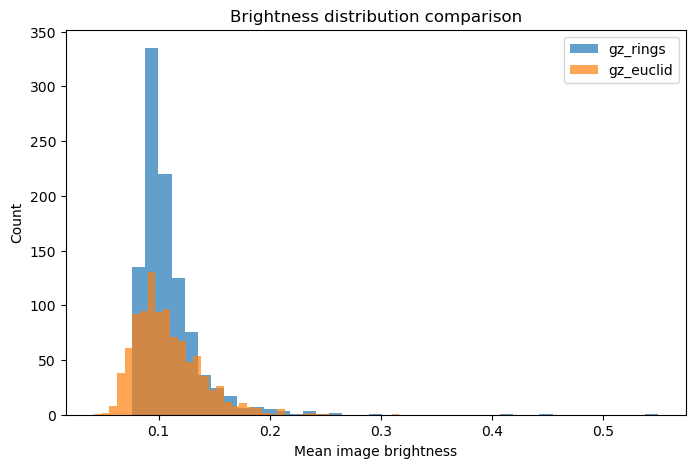

gz_rings brightness mean/std: 0.10936122 0.032370146
gz_euclid brightness mean/std: 0.10801208 0.030639928


In [13]:
def mean_brightness_per_image(ds, n=1000):
    idxs = np.random.choice(len(ds), size=min(n, len(ds)), replace=False)
    vals = []
    for idx in idxs:
        img = to_numpy_image(ds[int(idx)]["image"]).astype(np.float32)
        if img.max() > 1.0:
            img = img / 255.0
        vals.append(img.mean())
    return np.array(vals)

rings_brightness = mean_brightness_per_image(gz_rings["train"], n=1000)
euclid_brightness = mean_brightness_per_image(gz_euclid["train"], n=1000)

plt.figure(figsize=(8, 5))
plt.hist(rings_brightness, bins=40, alpha=0.7, label="gz_rings")
plt.hist(euclid_brightness, bins=40, alpha=0.7, label="gz_euclid")
plt.xlabel("Mean image brightness")
plt.ylabel("Count")
plt.title("Brightness distribution comparison")
plt.legend()
plt.show()

print("gz_rings brightness mean/std:", rings_brightness.mean(), rings_brightness.std())
print("gz_euclid brightness mean/std:", euclid_brightness.mean(), euclid_brightness.std())

In [14]:
euclid_cols = gz_euclid["train"].column_names
meta_cols = [c for c in euclid_cols if c not in ["image"]]

print(f"Total Euclid columns: {len(euclid_cols)}")
print(f"Non-image columns: {len(meta_cols)}")

for c in meta_cols:
    print(c)

Total Euclid columns: 109
Non-image columns: 108
id_str
dataset_name
smooth-or-featured-euclid_smooth
smooth-or-featured-euclid_smooth_fraction
smooth-or-featured-euclid_total-votes
smooth-or-featured-euclid_featured-or-disk
smooth-or-featured-euclid_featured-or-disk_fraction
smooth-or-featured-euclid_problem
smooth-or-featured-euclid_problem_fraction
disk-edge-on-euclid_yes
disk-edge-on-euclid_yes_fraction
disk-edge-on-euclid_total-votes
disk-edge-on-euclid_no
disk-edge-on-euclid_no_fraction
has-spiral-arms-euclid_yes
has-spiral-arms-euclid_yes_fraction
has-spiral-arms-euclid_total-votes
has-spiral-arms-euclid_no
has-spiral-arms-euclid_no_fraction
bar-euclid_strong
bar-euclid_strong_fraction
bar-euclid_total-votes
bar-euclid_weak
bar-euclid_weak_fraction
bar-euclid_no
bar-euclid_no_fraction
bulge-size-euclid_dominant
bulge-size-euclid_dominant_fraction
bulge-size-euclid_total-votes
bulge-size-euclid_large
bulge-size-euclid_large_fraction
bulge-size-euclid_moderate
bulge-size-euclid_mo